# DS-3002 Assignment 4 — Preprocessing & Part A (Unsupervised Learning)

Notebook: `i232534.ipynb`

This notebook contains the full Part Pre (data preprocessing) and Part A (unsupervised learning) required by the assignment.
Follow the sections in order; run all cells top-to-bottom. Random seed is fixed to `42` for reproducibility.

## Environment & Imports

In [5]:
# Standard imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Ensure output directories exist
os.makedirs('data', exist_ok=True)
os.makedirs('plots', exist_ok=True)
print('Imports ready — kernel seed =', RANDOM_STATE)

Imports ready — kernel seed = 42


## Part Pre — Data Preprocessing
Load the processed Cleveland CSV if available; otherwise load raw and convert.
We produce: `data/X_train.csv`, `data/X_test.csv`, `data/y_train.csv`, `data/y_test.csv`, and `data/heart_disease_complete.csv`.

In [7]:
# Try to load an existing processed file, else load the CSV we created earlier
processed_path = 'data/heart_disease_complete.csv'
if os.path.exists(processed_path):
    df = pd.read_csv(processed_path)
    print('Loaded', processed_path)
else:
    # fallback: read the cleveland CSV we created earlier in the repo
    fallback = 'heart+disease/heart_disease_cleveland.csv'
    if not os.path.exists(fallback):
        raise FileNotFoundError('Cannot find dataset — place the CSV in heart+disease/ or data/')
    df = pd.read_csv(fallback)
    print('Loaded', fallback)

print('Dataset shape:', df.shape)
print(df.head().to_string(index=False))

Loaded data/heart_disease_complete.csv
Dataset shape: (297, 15)
 age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  num  target
63.0  1.0 1.0     145.0 233.0  1.0      2.0    150.0    0.0      2.3    3.0 0.0   6.0    0       0
67.0  1.0 4.0     160.0 286.0  0.0      2.0    108.0    1.0      1.5    2.0 3.0   3.0    2       1
67.0  1.0 4.0     120.0 229.0  0.0      2.0    129.0    1.0      2.6    2.0 2.0   7.0    1       1
37.0  1.0 3.0     130.0 250.0  0.0      0.0    187.0    0.0      3.5    3.0 0.0   3.0    0       0
41.0  0.0 2.0     130.0 204.0  0.0      2.0    172.0    0.0      1.4    1.0 0.0   3.0    0       0


In [8]:
# Handle missing values (assignment: '?' -> NaN already handled in files; ensure types)
df = df.replace('?', pd.NA)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('Missing values per column:', df.isnull().sum())

# Simple strategy for this dataset (small number of missing in Cleveland): drop rows with NA
initial_len = len(df)
df = df.dropna().reset_index(drop=True)
print(f'Rows dropped: {initial_len - len(df)}; new shape: {df.shape}')

# Convert target: 'num' > 0 -> disease (1), else 0
if 'num' in df.columns:
    df['target'] = (df['num'] > 0).astype(int)
else:
    raise KeyError('Expected column "num" in dataset')

# Save cleaned full table
df.to_csv('data/heart_disease_complete.csv', index=False)
print('Saved data/heart_disease_complete.csv')

Missing values per column: age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
target      0
dtype: int64
Rows dropped: 0; new shape: (297, 15)
Saved data/heart_disease_complete.csv


### Feature selection, encoding and scaling
We use the 13 features specified by the assignment: `age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal` and create binary target `target`.

In [9]:
features = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal']
missing_feats = [f for f in features if f not in df.columns]
if missing_feats:
    raise KeyError('Missing expected features: ' + ','.join(missing_feats))

X = df[features].copy()
y = df['target'].values

# Categorical columns per assignment
categorical_cols = ['cp','restecg','slope','thal']
continuous_cols = [c for c in features if c not in categorical_cols]

print('Categorical:', categorical_cols)
print('Continuous:', continuous_cols)

# Train/test split (stratified, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train/test sizes:', X_train.shape[0], X_test.shape[0])

# One-hot encode categoricals (drop='first' to avoid collinearity)
ohe = OneHotEncoder(sparse_output=False, drop='first')
X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])
cat_names = list(ohe.get_feature_names_out(categorical_cols))

# Scale continuous features
scaler = StandardScaler()
X_train_cont = scaler.fit_transform(X_train[continuous_cols])
X_test_cont = scaler.transform(X_test[continuous_cols])

# Assemble final DataFrames
X_train_proc = pd.DataFrame(X_train_cont, columns=continuous_cols, index=X_train.index).reset_index(drop=True)
X_train_proc = pd.concat([X_train_proc, pd.DataFrame(X_train_cat, columns=cat_names)], axis=1)

X_test_proc = pd.DataFrame(X_test_cont, columns=continuous_cols, index=X_test.index).reset_index(drop=True)
X_test_proc = pd.concat([X_test_proc, pd.DataFrame(X_test_cat, columns=cat_names)], axis=1)

print('Processed feature count:', X_train_proc.shape[1])

# Optional: Apply SMOTE to training set (kept commented; enable if desired)
apply_smote = True
if apply_smote:
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train_smote, y_train_smote = sm.fit_resample(X_train_proc, y_train)
    print('After SMOTE training size:', X_train_smote.shape)
else:
    X_train_smote, y_train_smote = X_train_proc, y_train

# Save processed sets
X_train_proc.to_csv('data/X_train.csv', index=False)
X_test_proc.to_csv('data/X_test.csv', index=False)
pd.Series(y_train).to_csv('data/y_train.csv', index=False)
pd.Series(y_test).to_csv('data/y_test.csv', index=False)
pd.DataFrame(X_train_smote, columns=X_train_proc.columns).to_csv('data/X_train_smote.csv', index=False)
pd.Series(y_train_smote).to_csv('data/y_train_smote.csv', index=False)
print('Saved processed files to data/')

Categorical: ['cp', 'restecg', 'slope', 'thal']
Continuous: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca']
Train/test sizes: 237 60
Processed feature count: 18
After SMOTE training size: (256, 18)
Saved processed files to data/


## Part A — Unsupervised Learning
This section runs K-Means (k=2..8), hierarchical clustering (Ward), PCA and t-SNE visualizations, and reports ARI and silhouette scores.

Full dataset shape for unsupervised: (297, 18)
k=2: inertia=2541.53, silhouette=0.1779
k=3: inertia=2306.81, silhouette=0.1388
k=4: inertia=2113.15, silhouette=0.1492
k=5: inertia=1993.39, silhouette=0.1366
k=6: inertia=1885.05, silhouette=0.1341
k=7: inertia=1808.84, silhouette=0.1296
k=8: inertia=1745.56, silhouette=0.1215


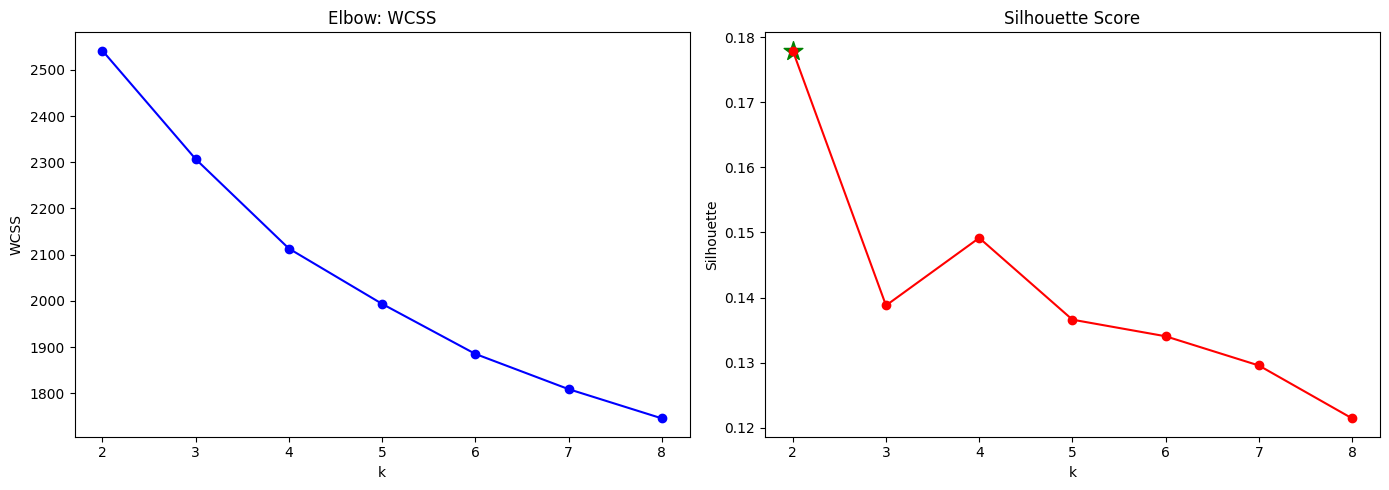

Best k by silhouette: 2


In [10]:
# Combine train/test (unsupervised tasks operate on full dataset)
X_full = pd.concat([pd.read_csv('data/X_train.csv'), pd.read_csv('data/X_test.csv')], axis=0).reset_index(drop=True)
y_full = np.concatenate([pd.read_csv('data/y_train.csv').values.ravel(), pd.read_csv('data/y_test.csv').values.ravel()])
print('Full dataset shape for unsupervised:', X_full.shape)

# K-Means: test k values
k_values = [2,3,4,5,6,7,8]
wcss = []
sil_scores = []
labels_store = {}
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_full)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_full, km.labels_))
    labels_store[k] = km.labels_
    print(f'k={k}: inertia={km.inertia_:.2f}, silhouette={sil_scores[-1]:.4f}')

# Plot elbow and silhouette
fig, ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(k_values, wcss, 'bo-'); ax[0].set_title('Elbow: WCSS'); ax[0].set_xlabel('k'); ax[0].set_ylabel('WCSS')
ax[1].plot(k_values, sil_scores, 'ro-'); ax[1].set_title('Silhouette Score'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette')
best_k = k_values[int(np.argmax(sil_scores))]
ax[1].scatter([best_k],[max(sil_scores)], s=200, c='green', marker='*')
plt.tight_layout(); plt.savefig('plots/partA_k_elbow_silhouette.png', dpi=300); plt.show()
print('Best k by silhouette:', best_k)

KMeans chosen_k= 2
Silhouette (final): 0.1779043990867808
Inertia: 2541.533105240228
Cluster sizes: [178, 119]
PCA 2D explained variance ratio: [0.23799575 0.13821267]


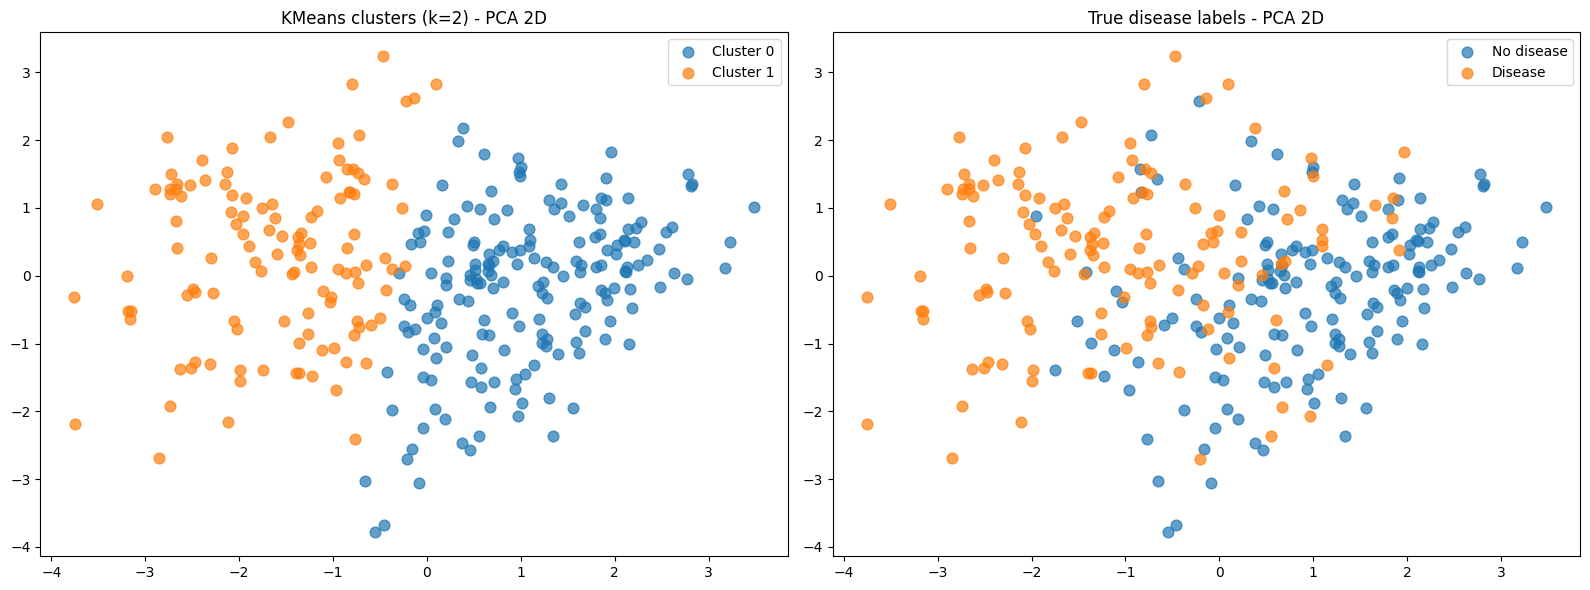

Adjusted Rand Index (KMeans vs true labels): 0.35292750612835166


In [11]:
# Train final k-means (choose best_k for silhouette but keep interpretability)
chosen_k = best_k
km_final = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=20)
km_labels = km_final.fit_predict(X_full)
print('KMeans chosen_k=', chosen_k)
print('Silhouette (final):', silhouette_score(X_full, km_labels))
print('Inertia:', km_final.inertia_)
print('Cluster sizes:', [int((km_labels==i).sum()) for i in range(chosen_k)])

# PCA 2D for visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca.fit_transform(X_full)
print('PCA 2D explained variance ratio:', pca.explained_variance_ratio_)

fig, axes = plt.subplots(1,2,figsize=(16,6))
# plot clusters
for i in range(chosen_k):
    axes[0].scatter(X_pca2[km_labels==i,0], X_pca2[km_labels==i,1], s=60, alpha=0.7, label=f'Cluster {i}')
axes[0].set_title(f'KMeans clusters (k={chosen_k}) - PCA 2D')
axes[0].legend()
# plot true labels
for lab in [0,1]:
    axes[1].scatter(X_pca2[y_full==lab,0], X_pca2[y_full==lab,1], s=60, alpha=0.7, label=('No disease' if lab==0 else 'Disease'))
axes[1].set_title('True disease labels - PCA 2D')
axes[1].legend()
plt.tight_layout(); plt.savefig('plots/partA_pca_clusters.png', dpi=300); plt.show()

# ARI between clusters and true labels
ari_km = adjusted_rand_score(y_full, km_labels)
print('Adjusted Rand Index (KMeans vs true labels):', ari_km)

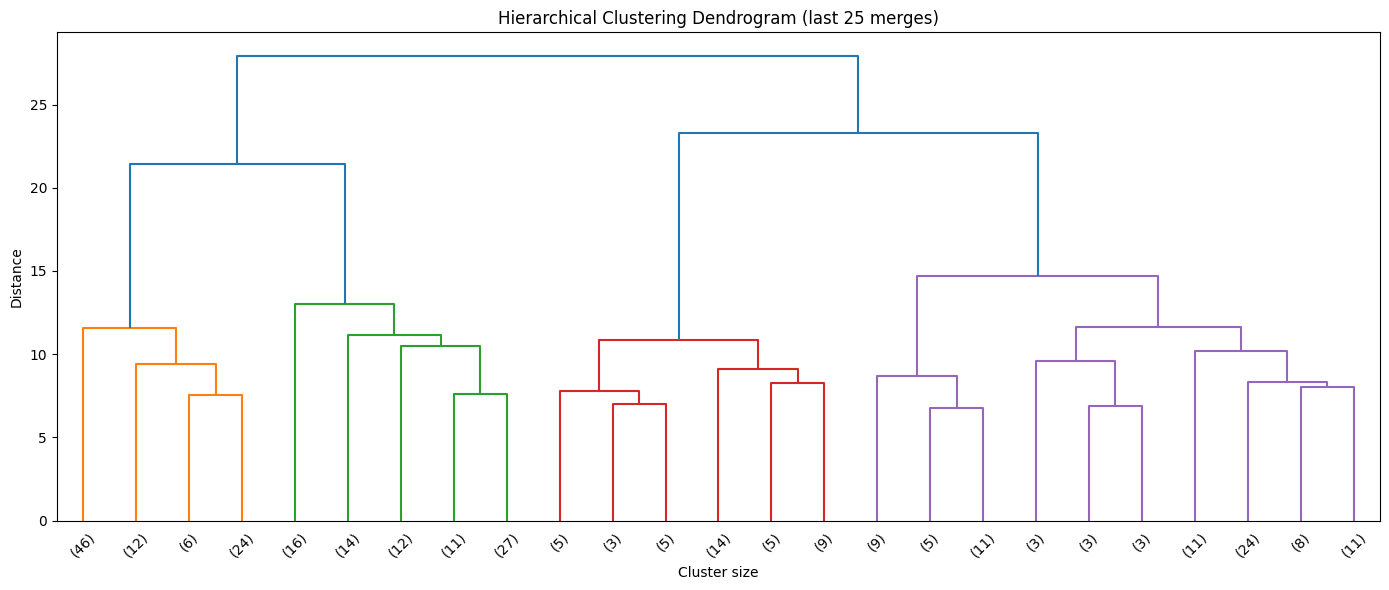

Hierarchical silhouette: 0.14087328577992442
Hierarchical ARI vs true labels: 0.17432583671732946

Crosstab (hierarchical cluster vs true label)
 col_0    0   1
row_0         
0       39  90
1      121  47


In [13]:
# Hierarchical clustering (Ward)
linkage_matrix = linkage(X_full, method='ward')
plt.figure(figsize=(14,6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=25)
plt.title('Hierarchical Clustering Dendrogram (last 25 merges)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.tight_layout(); plt.savefig('plots/partA_dendrogram.png', dpi=300); plt.show()
# Agglomerative clustering labels (k = chosen_k)
hc = AgglomerativeClustering(n_clusters=chosen_k, linkage='ward')
hc_labels = hc.fit_predict(X_full)
print('Hierarchical silhouette:', silhouette_score(X_full, hc_labels))
print('Hierarchical ARI vs true labels:', adjusted_rand_score(y_full, hc_labels))
# Crosstab
print('\nCrosstab (hierarchical cluster vs true label)\n', pd.crosstab(hc_labels, y_full))

Components for 90% variance: 10


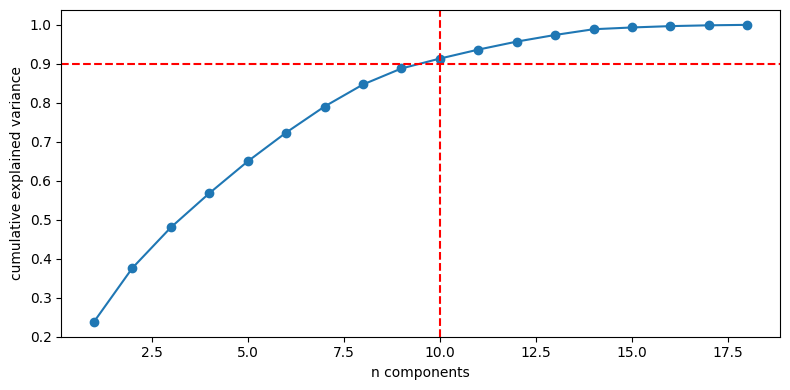

Running t-SNE (this can take ~1-3s for this dataset)...


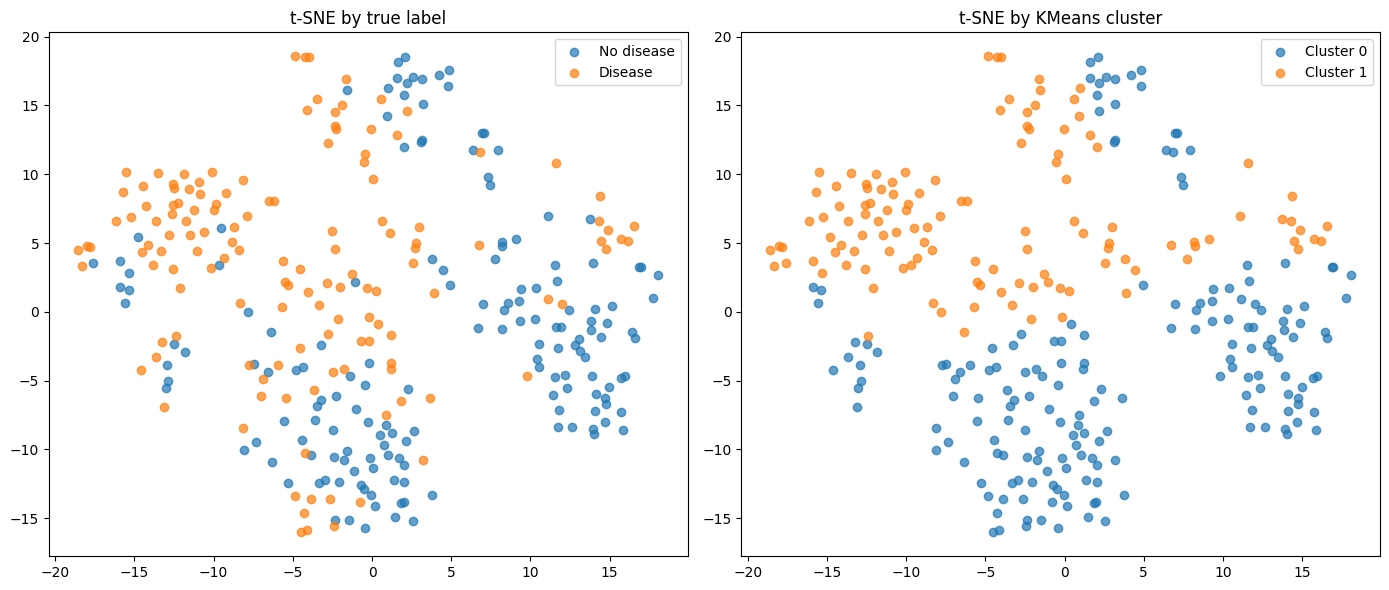

Summary:
 KMeans silhouette: 0.1779043990867808
 KMeans ARI vs true labels: 0.35292750612835166
 Hierarchical silhouette: 0.14087328577992442
 Hierarchical ARI vs true labels: 0.17432583671732946
Part A complete — plots saved to /plots, processed data in /data


In [14]:
# PCA full explained variance to find components for 90%
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_full)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cumsum >= 0.90) + 1)
print('Components for 90% variance:', n_90)
plt.figure(figsize=(8,4))
plt.plot(range(1, len(cumsum)+1), cumsum, marker='o')
plt.axhline(0.90, color='red', linestyle='--')
plt.axvline(n_90, color='red', linestyle='--')
plt.xlabel('n components'); plt.ylabel('cumulative explained variance')
plt.tight_layout(); plt.savefig('plots/partA_pca_cumulative.png', dpi=300); plt.show()

# t-SNE (use max_iter to be compatible with sklearn version)
print('Running t-SNE (this can take ~1-3s for this dataset)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto', max_iter=1000)
X_tsne = tsne.fit_transform(X_full)
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.scatter(X_tsne[y_full==0,0], X_tsne[y_full==0,1], label='No disease', alpha=0.7)
plt.scatter(X_tsne[y_full==1,0], X_tsne[y_full==1,1], label='Disease', alpha=0.7)
plt.title('t-SNE by true label')
plt.legend()
plt.subplot(1,2,2)
for i in range(chosen_k):
    plt.scatter(X_tsne[km_labels==i,0], X_tsne[km_labels==i,1], alpha=0.7, label=f'Cluster {i}')
plt.title('t-SNE by KMeans cluster')
plt.legend()
plt.tight_layout(); plt.savefig('plots/partA_tsne.png', dpi=300); plt.show()

# Summary metrics
print('Summary:')
print(' KMeans silhouette:', silhouette_score(X_full, km_labels))
print(' KMeans ARI vs true labels:', adjusted_rand_score(y_full, km_labels))
print(' Hierarchical silhouette:', silhouette_score(X_full, hc_labels))
print(' Hierarchical ARI vs true labels:', adjusted_rand_score(y_full, hc_labels))

print('Part A complete — plots saved to /plots, processed data in /data')